<a href="https://colab.research.google.com/github/Deepaksoni-dot/Deepaksoni-dot/blob/MachineLearning/PCA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: code for PCA model on sklearn.datasets load digits
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
# prompt: standard scale X

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [ ]:
# prompt: calculate covariance of X

covariance_matrix = np.cov(X_scaled, rowvar=False)
covariance_matrix


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [ ]:
covariance_matrix.shape

(64, 64)

In [ ]:
min(covariance_matrix.flatten())

-0.57051363323811

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print("Eigenvalues:", eigenvalues)
#print("Eigenvectors:", eigenvectors)

Eigenvalues: [7.34477606 5.83549054 5.15396118 3.96623597 2.9663452  2.57204442
 2.40600941 2.06867355 1.82993314 1.78951739 1.69784616 1.57287889
 1.38870781 1.35933609 1.32152536 1.16829176 1.08368678 0.99977862
 0.97438293 0.90891242 0.82271926 0.77631014 0.71155675 0.64552365
 0.59527399 0.5765018  0.52673155 0.5106363  0.48686381 0.45560107
 0.44285155 0.42230086 0.3991063  0.39110111 0.36094517 0.34860306
 0.3195963  0.05037444 0.29406627 0.27692285 0.06328961 0.258273
 0.24783029 0.2423566  0.07635394 0.08246812 0.09018543 0.09840876
 0.10250434 0.11188655 0.11932898 0.12426371 0.13321081 0.14311427
 0.217582   0.15818474 0.16875236 0.20799593 0.17612894 0.2000909
 0.18983516 0.         0.         0.        ]


In [ ]:
sum=np.cumsum(eigenvalues)
sum

array([ 7.34477606, 13.1802666 , 18.33422778, 22.30046374, 25.26680894,
       27.83885336, 30.24486277, 32.31353632, 34.14346946, 35.93298685,
       37.63083301, 39.2037119 , 40.59241971, 41.9517558 , 43.27328116,
       44.44157292, 45.5252597 , 46.52503832, 47.49942125, 48.40833366,
       49.23105293, 50.00736307, 50.71891982, 51.36444347, 51.95971746,
       52.53621925, 53.06295081, 53.57358711, 54.06045092, 54.51605199,
       54.95890354, 55.38120441, 55.78031071, 56.17141182, 56.53235699,
       56.88096005, 57.20055635, 57.25093079, 57.54499706, 57.82191991,
       57.88520952, 58.14348253, 58.39131281, 58.63366941, 58.71002336,
       58.79249148, 58.88267691, 58.98108567, 59.08359001, 59.19547656,
       59.31480554, 59.43906925, 59.57228006, 59.71539433, 59.93297633,
       60.09116107, 60.25991343, 60.46790936, 60.6440383 , 60.8441292 ,
       61.03396437, 61.03396437, 61.03396437, 61.03396437])

In [ ]:
pca=PCA(n_components=21)
pca.fit_transform(X)
np.cumsum(pca.explained_variance_ratio_)

array([0.14890594, 0.28509365, 0.40303959, 0.48713938, 0.54496353,
       0.59413263, 0.6372925 , 0.67390623, 0.70743871, 0.73822677,
       0.76195018, 0.78467714, 0.80289578, 0.82063433, 0.83530534,
       0.84940249, 0.86258838, 0.87506976, 0.88524694, 0.89430312,
       0.9031985 ])

In [ ]:
X_recovered=pca.inverse_transform(pca.transform(X))

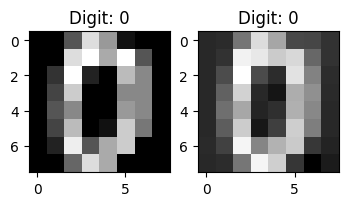

In [ ]:
plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.imshow(np.reshape(X[0], (8, 8)), cmap='gray')
plt.title(f"Digit: {y[0]}")
plt.subplot(1,2,2)
plt.imshow(np.reshape(X_recovered[0], (8, 8)), cmap='gray')
plt.title(f"Digit: {y[0]}")
plt.show()